In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000
        ))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv = cv,
        scoring='accuracy'
    )

    print(
        f'name {name:20s} ',
        f'score mean {scores.mean():.4f} ',
        f'score std {scores.std()}'
    )

name Logistic Regression   score mean 0.9583  score std 0.026352313834736508
name KNN                   score mean 0.9583  score std 0.026352313834736508


In [18]:
from sklearn.model_selection import GridSearchCV

lr_param = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    estimator=models['Logistic Regression'],
    param_grid=lr_param,
    cv=cv,
    scoring='accuracy',
    n_jobs=-2
)

lr_grid.fit(X_train, y_train)

print('B Params', lr_grid.best_params_)
print('B Score', lr_grid.best_score_)

B Params {'model__C': 10}
B Score 0.9666666666666668


In [28]:
knn_param = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    estimator=models['KNN'],
    param_grid=knn_param,
    cv=cv,
    scoring='accuracy',
    n_jobs=-2
)

knn_grid.fit(X_train, y_train)

print('B Params', knn_grid.best_params_)
print('B Score', knn_grid.best_score_)

B Params {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
B Score 0.9666666666666668


In [29]:
lr_best_model = lr_grid.best_estimator_
knn_best_model = knn_grid.best_estimator_

lr_pred = lr_best_model.predict(X_test)
knn_pred = knn_best_model.predict(X_test)

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print('Accuracy: \n',
      'lr: ', accuracy_score(y_test, lr_pred),
      'knn: ', accuracy_score(y_test, knn_pred))

print('Precision: \n',
      'lr: ', precision_score(y_test, lr_pred, average='weighted'),
      'knn: ', precision_score(y_test, knn_pred, average='weighted'))

print('recall: \n',
      'lr: ', recall_score(y_test, lr_pred, average='weighted'),
      'knn: ', recall_score(y_test, knn_pred, average='weighted'))

print('F1: \n',
      'lr: ', f1_score(y_test, lr_pred, average='weighted'),
      'knn: ', f1_score(y_test, knn_pred, average='weighted'))

print('Classification: \n',
      'lr: ', classification_report(y_test, lr_pred),
      'knn: ', classification_report(y_test, knn_pred))

Accuracy: 
 lr:  1.0 knn:  0.9333333333333333
Precision: 
 lr:  1.0 knn:  0.9444444444444445
recall: 
 lr:  1.0 knn:  0.9333333333333333
F1: 
 lr:  1.0 knn:  0.9326599326599326
Classification: 
 lr:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30
 knn:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



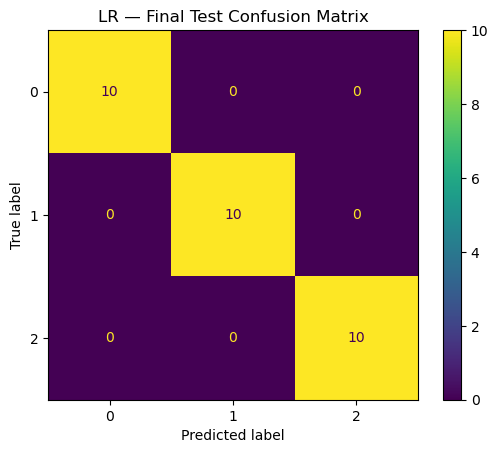

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.title("LR — Final Test Confusion Matrix")
plt.show()

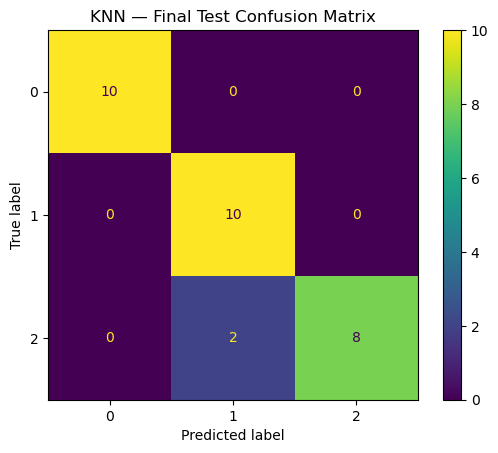

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

plt.title("KNN — Final Test Confusion Matrix")
plt.show()

Complete code in one
__________________

Best Parameters:
{'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}

Best CV Score:
0.9666666666666668

Test Accuracy: 0.9333333333333333
Test Precision: 0.9444444444444445
Test Recall: 0.9333333333333333
Test F1: 0.9326599326599326

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



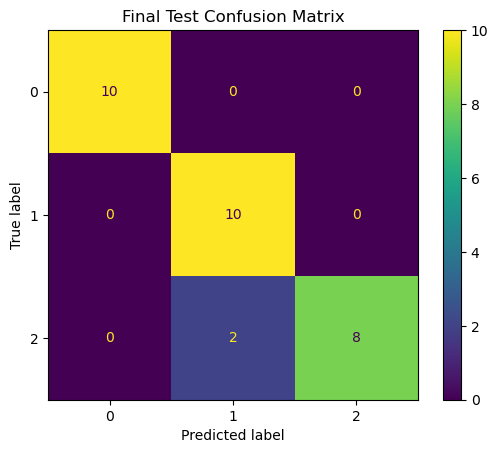

In [38]:
from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Load data
# --------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target


# --------------------------------------------------
# 2. Train/Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 3. Pipeline
# --------------------------------------------------

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])


# --------------------------------------------------
# 4. Hyperparameter Grid
# --------------------------------------------------

param_grid = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": [
        "uniform",
        "distance"
    ],
    "model__metric": [
        "euclidean",
        "manhattan"
    ]
}


# --------------------------------------------------
# 5. Cross Validation
# --------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# --------------------------------------------------
# 6. Grid Search
# --------------------------------------------------

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)


# --------------------------------------------------
# 7. Best Configuration
# --------------------------------------------------

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)


# --------------------------------------------------
# 8. Final Test Evaluation
# --------------------------------------------------

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)


print("\nTest Accuracy:",
      accuracy_score(y_test, y_pred))

print(
    "Test Precision:",
    precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "Test Recall:",
    recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "Test F1:",
    f1_score(
        y_test,
        y_pred,
        average="weighted"
    )
)


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# --------------------------------------------------
# 9. Confusion Matrix
# --------------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Final Test Confusion Matrix")
plt.show()

Workflow

                    DATA
                     │
                     ↓
              Train/Test Split
                /         \
               ↓           ↓
          Training        Test
             │              │
             ↓              │
      ┌────────────────┐    │
      │   Pipeline     │    │
      │                │    │
      │ Preprocessing  │    │
      │       ↓        │    │
      │     Model      │    │
      └───────┬────────┘    │
              ↓             │
       Cross Validation     │
              ↓             │
      Hyperparameter        │
           Tuning           │
              ↓             │
       Best Configuration   │
              ↓             │
        Final Pipeline      │
              │             │
              └──────┐      │
                     ↓      ↓
                  TEST DATA
                     ↓
                Predictions
                     ↓
        ┌─────────────────────┐
        │ Accuracy            │
        │ Precision           │
        │ Recall              │
        │ F1                  │
        │ Confusion Matrix    │
        └─────────────────────┘